In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import BoundaryNorm
from matplotlib.patches import Patch, Rectangle, Ellipse
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
from pathlib import Path

import sys
module_path = "../bin"
sys.path.insert(0,module_path)

import um_utils_plotting as umplt
import um_utils as um
import get_cpt
from geometry_fix import apply_geometry_collection_fix

apply_geometry_collection_fix()

um.WarningSuppress()

MEANS_DIR = Path("../Data/Models/Monthly_Means")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
#------------------------------------------------------------
# PNAS Figure Specification
#------------------------------------------------------------

PNAS_WIDTH = {1: 3.42, 1.5: 4.5, 2: 7.0}      # inches
PNAS_MAX_HEIGHT = 9.0

def pnas_figsize(cols, height):
    """Figure size in inches for a PNAS column count and chosen height."""
    if height > PNAS_MAX_HEIGHT:
        raise ValueError(f"height {height}in exceeds PNAS maximum of {PNAS_MAX_HEIGHT}in")
    return (PNAS_WIDTH[cols], height)

FS = {              # font sizes
    "panel": 8,     # (a), (b) ... panel letters
    "title": 8,     # panel titles
    "label": 7,     # axis and colorbar labels
    "tick": 6,      # tick labels
    "legend": 6,    # legend
    "annot": 6,     # Axes annotations
}

LW = {              # line widths 
    "spine": 0.8,   # axes spines
    "coast": 0.5,   # map coastlines
    "border": 0.3,  # map borders 
    "grid": 0.2,    # gridlines
    "contour": 0.1, # contours
    "data": 0.8,    # scatter point edgewidths
}

MS = {              # marker sizes
    "proxy": 10,    # scatter points
    "legend": 4,    # legend markers
}

plt.rcParams.update(plt.rcParamsDefault)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

In [ ]:
#------------------------------------------------------------
# Load Model Means
#------------------------------------------------------------

MH_means = xr.load_dataset(MEANS_DIR / "MH_monthly_means.nc", decode_times=False)
PI_means = xr.load_dataset(MEANS_DIR / "PI_monthly_means.nc", decode_times=False)

#------------------------------------------------------------
# PFT-parameters from model configuration
#------------------------------------------------------------

G_AREA = {"BrDe": 0.011, "BrEvTr": 0.007, "BrEvTe": 0.014, "NeDe": 0.010,
          "NeEv": 0.025, "C3Gr": 0.125, "C3Cr": 0.125, "C3Pa": 0.125,
          "C4Gr": 0.060, "C4Cr": 0.060, "C4Pa": 0.060, "ShDe": 0.060, "ShEv": 0.100}

CROP   = {"BrDe": 0, "BrEvTr": 0, "BrEvTe": 0, "NeDe": 0, "NeEv": 0, "C3Gr": 0,
          "C3Cr": 1, "C3Pa": 2, "C4Gr": 0, "C4Cr": 1, "C4Pa": 2, "ShDe": 0, "ShEv": 0}

A_WL    = {"BrDe": 0.78, "BrEvTr": 0.845, "BrEvTe": 0.78, "NeDe": 0.80, "NeEv": 0.65,
           "C3Gr": 0.005, "C3Cr": 0.005, "C3Pa": 0.005, "C4Gr": 0.005, "C4Cr": 0.005,
           "C4Pa": 0.005, "ShDe": 0.13, "ShEv": 0.13}

A_WS    = {"BrDe": 12, "BrEvTr": 13, "BrEvTe": 12, "NeDe": 10, "NeEv": 10,
           "C3Gr": 1, "C3Cr": 1, "C3Pa": 1, "C4Gr": 1, "C4Cr": 1, "C4Pa": 1,
           "ShDe": 13, "ShEv": 13}

LAI_MIN = {"BrDe": 1.0, "BrEvTr": 1.0, "BrEvTe": 1.0, "NeDe": 1.0, "NeEv": 1.0,
           "C3Gr": 0.3, "C3Cr": 0.3, "C3Pa": 0.3, "C4Gr": 0.3, "C4Cr": 0.3,
           "C4Pa": 0.3, "ShDe": 1.0, "ShEv": 1.0}

LAI_MAX = {"BrDe": 7.0, "BrEvTr": 9.0, "BrEvTe": 7.0, "NeDe": 5.0, "NeEv": 7.0,
           "C3Gr": 3.0, "C3Cr": 3.0, "C3Pa": 3.0, "C4Gr": 3.0, "C4Cr": 3.0,
           "C4Pa": 3.0, "ShDe": 4.0, "ShEv": 4.0}

B_WL    = {p: 1.667 for p in G_AREA}                    
ETA_SL  = {p: 0.01  for p in G_AREA}                    

NATURAL = [p for p, c in CROP.items() if c == 0]
AGRIC   = [p for p, c in CROP.items() if c > 0]
NONVEG  = ["Urban", "Lake"]                             
FRAC_MIN = 1.0e-6

#------------------------------------------------------------
# Parameters for Analysis
#------------------------------------------------------------

GROUPS = {"Trees and Shrubs": ["BrDe", "BrEvTr", "BrEvTe", "NeDe", "NeEv", "ShDe", "ShEv"],
          "Open Land":    ["C3Gr", "C4Gr"]}

AREA = np.cos(np.deg2rad(PI_means.latitude))
gp_mask = umplt.umRegionMask("GP", PI_means.longitude, PI_means.latitude)

npp_bins = np.linspace(-70, 30, 21)                  # ΔNPP (%)
stress_bins = np.linspace(-20, 60, 21)                  # Δmoisture stress (%)

#------------------------------------------------------------
# Helpers
#------------------------------------------------------------

def tile_frac(ds):
    """Cover fraction on the 13 PFT tiles, sharing the PFTs coordinate."""
    return (ds["surfacefrac"].isel(surface_tiles=slice(None, 13))
            .rename({"surface_tiles": "PFTs"}).assign_coords(PFTs=ds["PFTs"]))

def pft_param(d):
    """Per-PFT parameter dict as a DataArray on the PFTs coordinate."""
    return xr.DataArray([d[p] for p in PI_means.PFTs.values],
                        dims="PFTs", coords={"PFTs": PI_means.PFTs})

def gp_points(da):
    """Annual-mean GP grid-cell values as a flat array."""
    return (da.mean("time").where(gp_mask)
            .stack(points=("latitude", "longitude")).dropna("points").values)

def pct_change(var, names):
    """Group-mean MH-vs-PI change (%) for a PFT variable, per GP grid cell."""
    pi = gp_points(PI_means[var].sel(PFTs=names).mean("PFTs"))
    mh = gp_points(MH_means[var].sel(PFTs=names).mean("PFTs"))
    return (mh - pi) / pi * 100

def d_cover(names):
    """MH-vs-PI cover change of a PFT group, in % of grid-cell area."""
    frac = lambda ds: tile_frac(ds).sel(PFTs=names).sum("PFTs")
    return (gp_points(frac(MH_means)) - gp_points(frac(PI_means))) * 100

#------------------------------------------------------------
# Data for Panel (a)
#------------------------------------------------------------

bar_pfts = ["NeEv", "BrEvTe", "NeDe", "ShEv", "BrDe", "C3Gr", "C4Gr"]
bar_labels = ["NeEv", "BrEvTe", "NeDe", "ShEv", "BrDe", "C3", "C4"]

npp_decomp = pd.read_csv("../Data/Models/NPP_decomposition_MH_climstruct.csv").set_index("PFT").reindex(bar_pfts)

gp_mean = lambda da: float(da.mean("time").where(gp_mask).weighted(AREA).mean())
bar_cover = np.array([(gp_mean(MH_means["surfacefrac"].sel(surface_tiles=p))
                       - gp_mean(PI_means["surfacefrac"].sel(surface_tiles=p))) * 100
                      for p in bar_pfts])

#------------------------------------------------------------
# Data for Panels (b) and (c)
#------------------------------------------------------------

def bin2d(x, y, z, xbins, ybins):
    """Mean z per (ybins, xbins) cell; NaN where empty."""
    ix, iy = np.digitize(x, xbins) - 1, np.digitize(y, ybins) - 1
    ok = (ix >= 0) & (ix < len(xbins) - 1) & (iy >= 0) & (iy < len(ybins) - 1)
    grid = np.full((len(ybins) - 1, len(xbins) - 1), np.nan)
    for a, b in sorted(set(zip(iy[ok], ix[ok]))):
        grid[a, b] = z[ok][(iy[ok] == a) & (ix[ok] == b)].mean()
    if (~ok).any():
        print(f"warning: {(~ok).sum()}/{len(x)} points fall outside the bins")
    return grid


dcover_stress = {grp: bin2d(-pct_change("beta_factor", names),      # stress = -fsmc
                            pct_change("npp_nlimit_pft", names),
                            d_cover(names), stress_bins, npp_bins)
                 for grp, names in GROUPS.items()}

#------------------------------------------------------------
# Data for Panel (d)
#------------------------------------------------------------

def available_space(ds):
    """Area each natural PFT may colonise.
    Bare soil plus every shorter natural PFT, minus its own cover."""
    frac = tile_frac(ds)
    ht = ds["can_hgt"].sel(PFTs=NATURAL)
    nsub = len(NATURAL)

    order = xr.DataArray(np.arange(nsub), dims="PFTs", coords={"PFTs": ht.PFTs})
    key = ht - order * 1e-9                       # ties break on tile order
    com = key.rename({"PFTs": "m"}) >= key.rename({"PFTs": "n"})

    occupied = (com * frac.sel(PFTs=NATURAL).rename({"PFTs": "m"})).sum("m").rename({"n": "PFTs"})
    rank = com.sum("m").rename({"n": "PFTs"})   # 1 = tallest

    nonveg = ds["surfacefrac"].sel(surface_tiles=NONVEG).sum("surface_tiles")
    agric = frac.sel(PFTs=AGRIC).sum("PFTs")       # proxy for frac_agric

    space = 1.0 - nonveg - agric - FRAC_MIN * (nsub - rank) - occupied
    return space.assign_coords(PFTs=ht.PFTs).clip(0.0, None).reindex(PFTs=PI_means.PFTs)

def spreading_fraction(ds):
    """lambda: the NPP fraction spent on spreading"""
    lai_bal = (a_ws * eta_sl * ds["can_hgt"] / a_wl) ** (1.0 / (b_wl - 1.0))
    return ((lai_bal - lai_min) / (lai_max - lai_min)).clip(0.0, 1.0)

a_wl, a_ws, b_wl, eta_sl = (pft_param(d) for d in (A_WL, A_WS, B_WL, ETA_SL))
lai_min, lai_max = pft_param(LAI_MIN), pft_param(LAI_MAX)

g_area = pft_param(G_AREA)
lam_pi = spreading_fraction(PI_means)
pcs_pi = (lam_pi * PI_means["npp_nlimit_pft"]).mean("time")   # lambda*Pi
c_veg_pi = PI_means["veg_carbon_pft"].mean("time")
space_pi = available_space(PI_means).mean("time")
frac_pi = tile_frac(PI_means).mean("time")

def group_space(names):
    """Space open to the group, PI-cover-weighted over members (% of grid cell)."""
    w = frac_pi.sel(PFTs=names)
    da = (space_pi.sel(PFTs=names) * w).sum("PFTs") / w.sum("PFTs")
    return da.where(gp_mask).stack(points=("latitude", "longitude")).dropna("points").values * 100

def group_capacity(names):
    """Spreading carbon / carbon destroyed by disturbance each year."""
    da = (pcs_pi.sel(PFTs=names).sum("PFTs")
          / (c_veg_pi * g_area).sel(PFTs=names).sum("PFTs"))
    return da.where(gp_mask).stack(points=("latitude", "longitude")).dropna("points").values

plane = {grp: dict(space=group_space(names), capacity=group_capacity(names),
                   dcover=d_cover(names))
         for grp, names in GROUPS.items()}


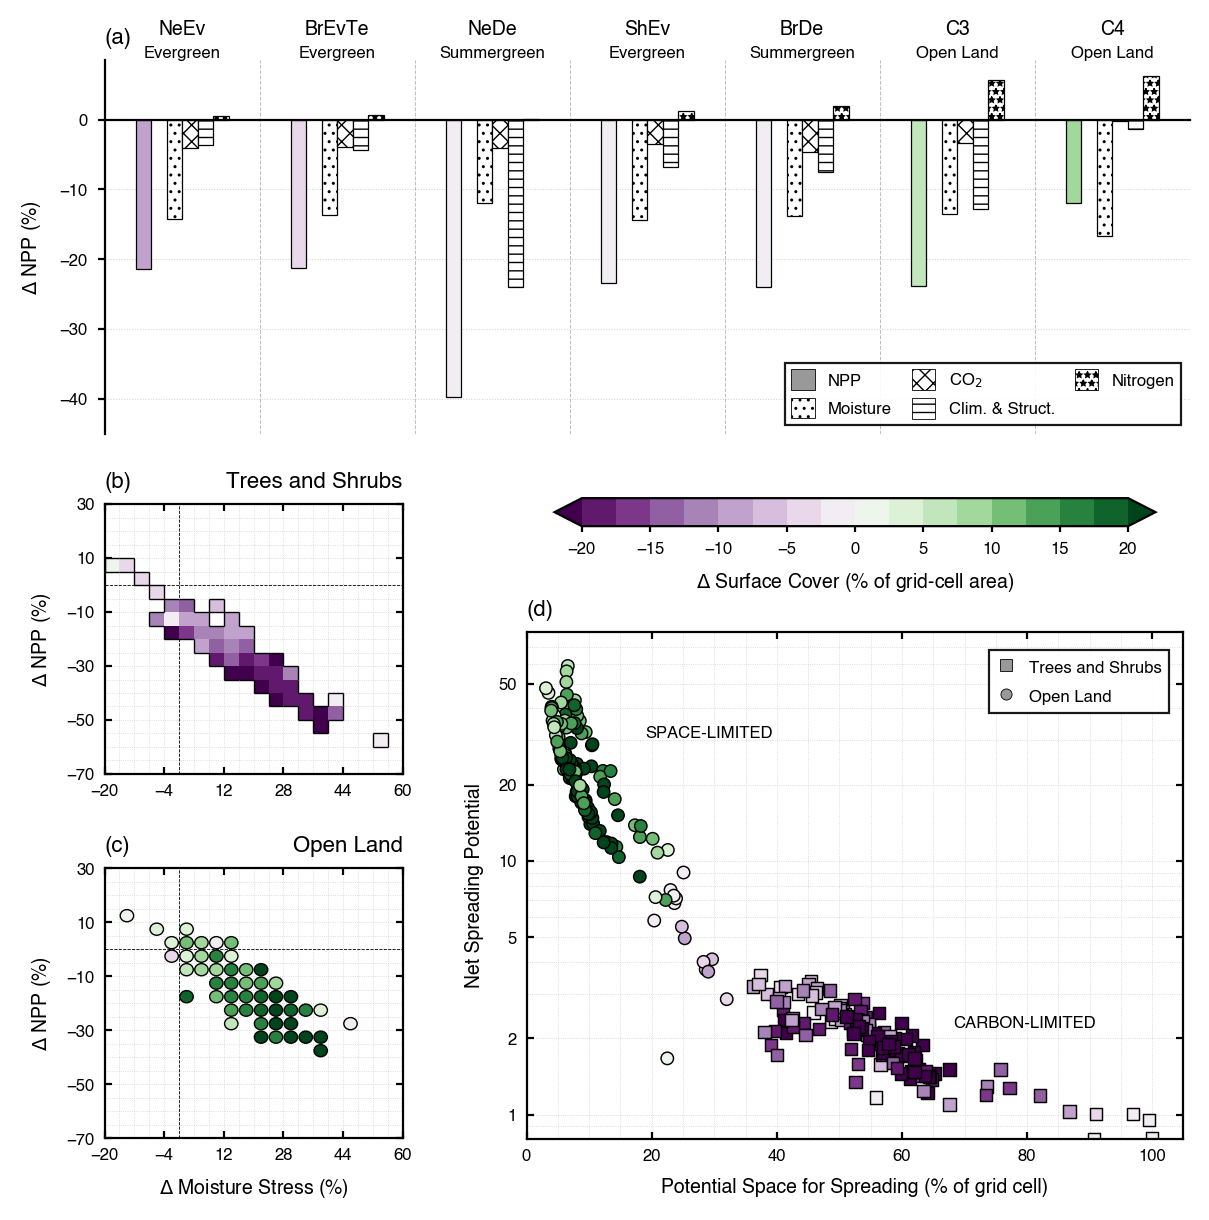

In [ ]:
#------------------------------------------------------------
# Shared Properties
#------------------------------------------------------------

cmap = cm.PRGn
v = 20
levels = np.linspace(-v, v, 17)
norm = BoundaryNorm(levels, cmap.N, extend="both")
cbar_label = r"$\Delta$ Surface Cover (% of grid-cell area)"

CELL_LW = 0.5       # ellipse and envelope edges in (b, c)
PLANE_S = 20        # scatter marker area in (d), points**2
HATCH_LW = 0.5      # hatch stroke width in (a)

plt.rcParams["hatch.linewidth"] = HATCH_LW

# Marker/patch identity of each group, shared by panels (b), (c), (d) and the legend
GROUP_STYLE = {
    "Trees and Shrubs": {"marker": "s", "patch": "rect", "outline": True},
    "Open Land": {"marker": "o", "patch": "ellipse", "outline": False},
}

#------------------------------------------------------------
# Shared Helpers
#------------------------------------------------------------

def style_ticks(ax):
    """Inward ticks on all four sides, minor ticks unlabelled."""
    ax.tick_params(width=LW["spine"], labelsize=FS["tick"], direction="in",
                   top=True, right=True, length=2.5)
    ax.tick_params(which="minor", length=0)


def style_spines(ax, lw=None):
    """Spines drawn over the plotted data."""
    for sp in ax.spines.values():
        sp.set_zorder(5)
        sp.set_linewidth(LW["spine"] if lw is None else lw)

#------------------------------------------------------------
# Layout
#------------------------------------------------------------

fig = plt.figure(figsize=pnas_figsize(2, 7.0), dpi=200)
outer = fig.add_gridspec(2, 1, height_ratios=[1.0, 1.7], hspace=0.14)
gs_b = outer[1].subgridspec(2, 3, hspace=0.35, wspace=0.32)

ax_bar = fig.add_subplot(outer[0])
ax_t = fig.add_subplot(gs_b[0, 0])
ax_o = fig.add_subplot(gs_b[1, 0], sharex=ax_t, sharey=ax_t)
ax_g = fig.add_subplot(gs_b[:, 1:])

#------------------------------------------------------------
# Properties for NPP Decomposition
#------------------------------------------------------------

bar_series = [
    {"col": "actual_npp", "label": "NPP", "hatch": None},
    {"col": "moisture", "label": "Moisture", "hatch": "...."},
    {"col": "co2", "label": "CO$_2$", "hatch": "xxxx"},
    {"col": "climstruct", "label": "Clim. & Struct.", "hatch": "----"},
    {"col": "nitrogen", "label": "Nitrogen", "hatch": "****"},
]
sub_labels = ["Evergreen", "Evergreen", "Summergreen", "Evergreen",
              "Summergreen", "Open Land", "Open Land"]

xpos = np.arange(len(bar_pfts))
bar_width = 0.1
offsets = np.array([-2.5, -0.5, 0.5, 1.5, 2.5]) * bar_width

label_y, sub_y = 13.0, 9.5      # data coords for the PFT names above the bars

#------------------------------------------------------------
# Plotting NPP Decomposition
#------------------------------------------------------------

for series, off in zip(bar_series, offsets):
    filled = series["hatch"] is None
    ax_bar.bar(xpos + off, npp_decomp[series["col"]].values, bar_width,
               edgecolor="black", linewidth=LW["border"] * 1.5, hatch=series["hatch"], zorder=2,
               facecolor=[cmap(norm(c)) for c in bar_cover] if filled else "white")

for i, (label, sub) in enumerate(zip(bar_labels, sub_labels)):
    ax_bar.axvline(i + 0.5, ls="dashed", lw=LW["border"] * 1.2, color="black", alpha=0.25)
    ax_bar.text(i, label_y, label, ha="center", va="center", fontsize=FS["label"])
    ax_bar.text(i, sub_y, sub, ha="center", va="center", fontsize=FS["tick"])

ax_bar.set_ylabel(r"$\Delta$ NPP (%)", fontsize=FS["label"], labelpad=6)
ax_bar.set_xlim(xpos[0] - 0.5, xpos[-1] + 0.5)
ax_bar.set_ylim(bottom=-45)
ax_bar.grid(True, axis="y", color="lightgrey", ls="dotted", lw=LW["border"] * 1.2, zorder=0)
ax_bar.tick_params(axis="x", bottom=False, labelbottom=False)
ax_bar.tick_params(axis="y", labelsize=FS["tick"], length=2.5)
ax_bar.spines["bottom"].set_position(("data", 0))
ax_bar.spines[["top", "right"]].set_visible(False)
ax_bar.spines[["left", "bottom"]].set_linewidth(LW["spine"])
ax_bar.set_title("(a)", loc="left", pad=6, size=FS["panel"])

bar_handles = [Patch(facecolor="0.6" if s["hatch"] is None else "white", edgecolor="black",
                     linewidth=LW["border"], hatch=s["hatch"], label=s["label"])
               for s in bar_series]
leg = ax_bar.legend(handles=bar_handles, loc="lower right", ncol=3, fancybox=False,
                    edgecolor="black", framealpha=0.9, handlelength=1.4, handleheight=1.5,
                    fontsize=FS["legend"], columnspacing=1.2)
leg.get_frame().set_linewidth(LW["spine"])

#------------------------------------------------------------
# Properties for Binned Panels
#------------------------------------------------------------

def draw_cells(ax, grid, xbins, ybins, patch):
    """Occupied bins coloured by Δcover: filled rectangles or outlined ellipses."""
    for a, b in zip(*np.nonzero(np.isfinite(grid))):
        x0, y0 = xbins[b], ybins[a]
        dx, dy = xbins[b + 1] - x0, ybins[a + 1] - y0
        colour = cmap(norm(grid[a, b]))

        if patch == "ellipse":
            ax.add_patch(Ellipse((x0 + dx / 2, y0 + dy / 2), 0.9 * dx, 0.9 * dy,
                                 facecolor=colour, edgecolor="black", lw=CELL_LW, zorder=3))
        else:
            ax.add_patch(Rectangle((x0, y0), dx, dy, facecolor=colour,
                                   edgecolor="none", zorder=3))


def draw_outline(ax, grid, xbins, ybins):
    """Perimeter of the occupied cells, marking the group's envelope."""
    mask, segs = np.isfinite(grid), []
    pad = np.pad(mask, 1, constant_values=False)

    for a, b in zip(*np.nonzero(mask)):
        x0, x1, y0, y1 = xbins[b], xbins[b + 1], ybins[a], ybins[a + 1]
        if not pad[a + 1, b]:
            segs.append([(x0, y0), (x0, y1)])       # left
        if not pad[a + 1, b + 2]:
            segs.append([(x1, y0), (x1, y1)])       # right
        if not pad[a, b + 1]:
            segs.append([(x0, y0), (x1, y0)])       # bottom
        if not pad[a + 2, b + 1]:
            segs.append([(x0, y1), (x1, y1)])       # top

    ax.add_collection(LineCollection(segs, colors="black", linewidths=CELL_LW, zorder=4))


def style_binned(ax, xbins, ybins, xlabel):
    """Shared axis styling for the binned panels."""
    ax.set_xlim(xbins[0], xbins[-1])
    ax.set_ylim(ybins[0], ybins[-1])

    ax.set_xticks(xbins[::4])
    ax.set_xticks(xbins, minor=True)
    ax.set_yticks(ybins[::4])
    ax.set_yticks(ybins, minor=True)

    ax.set_xlabel(xlabel, size=FS["label"], labelpad=5)
    ax.set_ylabel(r"$\Delta$ NPP (%)", size=FS["label"], labelpad=5)

    ax.grid(True, which="both", color="lightgrey", lw=LW["border"], ls="dotted", zorder=0)
    ax.axhline(0, color="black", ls="dashed", lw=LW["border"])
    ax.axvline(0, color="black", ls="dashed", lw=LW["border"])

    style_ticks(ax)
    style_spines(ax)


stress_label = r"$\Delta$ Moisture Stress (%)"   # on (c) only, the panels share x

binned_configs = [
    {"ax": ax_t, "group": "Trees and Shrubs", "label": "(b)", "xlabel": ""},
    {"ax": ax_o, "group": "Open Land", "label": "(c)", "xlabel": stress_label},
]

#------------------------------------------------------------
# Plotting Binned Panels
#------------------------------------------------------------

for cfg in binned_configs:
    ax, grp = cfg["ax"], cfg["group"]
    grid, style = dcover_stress[grp], GROUP_STYLE[grp]

    draw_cells(ax, grid, stress_bins, npp_bins, style["patch"])
    if style["outline"]:
        draw_outline(ax, grid, stress_bins, npp_bins)

    style_binned(ax, stress_bins, npp_bins, cfg["xlabel"])
    ax.set_title(cfg["label"], loc="left", pad=6, size=FS["panel"])
    ax.set_title(grp, loc="right", pad=6, size=FS["title"])

#------------------------------------------------------------
# Properties for Spreading Plane
#------------------------------------------------------------

space_label = "Potential Space for Spreading (% of grid cell)"
capacity_label = "Net Spreading Potential"
capacity_ticks = [1, 2, 5, 10, 20, 50]

regime_labels = [("SPACE-LIMITED", (0.18, 0.80)), ("CARBON-LIMITED", (0.65, 0.23))]

#------------------------------------------------------------
# Plotting Spreading Plane
#------------------------------------------------------------

for grp, d in plane.items():
    ax_g.scatter(d["space"], d["capacity"], c=d["dcover"], cmap=cmap, norm=norm,
                 marker=GROUP_STYLE[grp]["marker"], s=PLANE_S, edgecolor="black",
                 linewidth=LW["border"] * 1.75, zorder=3)

# xs = np.linspace(2, 105, 400)
# ax_g.plot(xs, 100.0 / xs, color="black", ls="dashed", lw=1.2, zorder=2)

ax_g.set_yscale("log")
ax_g.set_xlim(0, 105)
ax_g.set_ylim(0.8, 80)
ax_g.set_xticks(np.arange(0, 101, 20))
ax_g.set_xticks(np.arange(0, 106, 5), minor=True)
ax_g.set_yticks(capacity_ticks, labels=[f"{y:g}" for y in capacity_ticks])

ax_g.set_xlabel(space_label, size=FS["label"], labelpad=5)
ax_g.set_ylabel(capacity_label, size=FS["label"], labelpad=5)
ax_g.set_title("(d)", loc="left", pad=6, size=FS["panel"])
ax_g.grid(True, which="both", color="lightgrey", lw=LW["border"], ls="dotted", zorder=0)

style_ticks(ax_g)
style_spines(ax_g)

# Both labels sit in empty corners, each beside the cluster it describes
for text, xy in regime_labels:
    ax_g.annotate(text, xy=xy, xycoords="axes fraction", ha="left", va="center",
                  size=FS["annot"])

grp_handles = [Line2D([], [], marker=GROUP_STYLE[g]["marker"], ls="", markerfacecolor="0.6",
                      markeredgecolor="black", markeredgewidth=LW["border"],
                      markersize=MS["legend"], label=g)
               for g in GROUPS]
grp_leg = ax_g.legend(handles=grp_handles, loc="upper right", bbox_to_anchor=(0.99, 0.98),
                      edgecolor="black", fancybox=False, fontsize=FS["legend"],
                      handlelength=1.2, handleheight=1.5, framealpha=0.9)
grp_leg.get_frame().set_linewidth(LW["spine"])

umplt.ax_adjust(ax_g, shrinky=0.8, shrinkx=0.95, shifty=-0.046, shiftx=0.008)

#------------------------------------------------------------
# Colorbar
#------------------------------------------------------------

fig.canvas.draw()
pos = ax_g.get_position()

cax = fig.add_axes([pos.x0 + 0.02, pos.y0 + 0.438, pos.width - 0.04, 0.02])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, orientation="horizontal", cax=cax)
cbar.ax.tick_params(labelsize=FS["tick"], length=2)
cbar.ax.minorticks_off()
cbar.set_label(cbar_label, size=FS["label"], labelpad=5)

plt.show()
